#### Base Agents: Sentiment + Technical with PPO and SAC

- Sentiment PPO
- Sentiment SAC
- Technical PPO
- Technical SAC


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3 import SAC, PPO
from sentiment_enviroment import SentimentEnv
from technical_enviroment import TechnicalEnv
from agent_wrapper import *
import warnings
from custom_function import add_regime_indicator
warnings.filterwarnings("ignore")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Configuration

All parameters in one place for easy experimentation


In [3]:

# Sentiment Agent Environment
sentiment_env_config = {
    'vol_window': 6,           # Rolling window for Sharpe-like reward (6 months)
    'transaction_cost': 0.002, # INCREASED from 0.001 (0.2% per trade)
    'verbose': 0,              # Silent during training
}

# Technical Agent Environment
technical_env_config = {
    'vol_window': 6,           # Rolling window for Sharpe-like reward (6 months)
    'transaction_cost': 0.002, # INCREASED from 0.001 (0.2% per trade)
    'verbose': 0,              # Silent during training
}

ppo_config = {
    # Learning rate - REDUCED for stability
    'learning_rate': 0.0005,   # REDUCED from 0.001 (slower learning)
    
    # Data collection
    'n_steps': 2048,           # Steps per rollout (keep as is)
    'batch_size': 256,          # REDUCED from 128 (more noise = less overfit)
    'n_epochs': 3,             # REDUCED from 5 (less data reuse)
    
    # Exploration - INCREASED to prevent premature convergence
    'ent_coef': 0.2,           # INCREASED from 0.05 (more exploration)
    
    # Discount and advantage estimation
    'gamma': 0.95,             # Discount factor (focus on near-term rewards)
    'gae_lambda': 0.9,         # GAE parameter (bias-variance tradeoff)
    
    # Policy update constraints
    'clip_range': 0.2,         # PPO clipping range (standard)
    'clip_range_vf': None,     # Value function clipping (None = no clip)
    
    # Loss function weights
    'vf_coef': 0.5,            # Value function coefficient
    
    # Gradient stability
    'max_grad_norm': 0.5,      # REDUCED gradient clipping (more stable)
    
    # Normalization
    'normalize_advantage': True,  # Normalize advantages (reduces variance)
    
    # Other
    'use_sde': False,          # State-dependent exploration (optional)
    'sde_sample_freq': -1,     # SDE sampling frequency
    'target_kl': None,         # Early stopping based on KL divergence (optional)
    
    # Verbosity
    'verbose': 1,
}

sac_config = {
    # Learning rate - REDUCED for stability
    'learning_rate': 0.0003,   # REDUCED from 0.001
    
    # Replay buffer - INCREASED for diversity
    'buffer_size': 50000,     # INCREASED from 50000 (more diverse experiences)
    'learning_starts': 700,   # INCREASED from 500 (more random exploration first)
    
    # Training
    'batch_size': 256,         # REDUCED from 256 (less overfitting)
    'train_freq': 1,           # Update every step
    'gradient_steps': 1,       # One gradient step per env step
    
    # Exploration - FIXED at higher value
    'ent_coef': 0.2,           # INCREASED from 'auto' (force more exploration)
    
    # Soft update
    'tau': 0.005,              # Soft update coefficient (slow target updates)
    
    # Discount factor
    'gamma': 0.95,             # Focus on near-term rewards
    
    # Network update
    'target_update_interval': 1,  # Update target network every step
    'target_entropy': 'auto',  # Automatic entropy target
    
    # Other
    'use_sde': False,          # State-dependent exploration
    'sde_sample_freq': -1,
    'use_sde_at_warmup': False,
    
    # Verbosity
    'verbose': 1,
}
training_config = {
    # Data split
    'train_ratio': 0.60,       # 60% for training
    'val_ratio': 0.20,         # 20% for validation
    
    # Training budget - REDUCED to prevent overfitting
    'timesteps': 100000,        # REDUCED from 100000 (stop before overfitting)
    
    # Algorithm selection
    'algorithm': 'both',       # 'ppo', 'sac', or 'both' - Train both algorithms to compare
    
    # Model saving
    'save_path': './models/',  # Directory for models and plots
}

early_stopping_config = {
    'eval_freq': 1000,         # Evaluate every 2000 steps (15 evals for 30K steps)
    'patience': 5,             # Stop if no improvement for 5 evaluations (10K steps)
    'min_delta': 0.01,          # Any improvement counts (let model learn)
}

# Regime Detection
regime_config = {
    'enabled': True,           # Enable regime indicators
    'window': 6,               # SMA window for regime (6 months)
}



In [4]:
price_data = pd.read_csv("input_data/monthly_prices.csv", index_col=0, parse_dates=True)
technical_features = pd.read_csv("input_data/technical_indicators.csv", index_col=0, parse_dates=True)
sentiment_features = pd.read_csv("input_data/nlp_features.csv", index_col=0, parse_dates=True)
common_dates = technical_features.index.intersection(sentiment_features.index)
price_data = price_data.loc[common_dates]
technical_features = technical_features.loc[common_dates]
sentiment_features = sentiment_features.loc[common_dates]

price_data.to_csv("output_data/price_data.csv")
technical_features.to_csv("output_data/technical_features.csv")
sentiment_features.to_csv("output_data/sentiment_features.csv")
# Check data quality
print(f"Total months: {len(price_data)}")
print(f"NaN in prices: {price_data.isnull().sum().sum()}")
print(f"Date range: {price_data.index[0].date()} to {price_data.index[-1].date()}")

Total months: 129
NaN in prices: 0
Date range: 2015-02-28 to 2025-10-31


## Add Market Regime Indicators

These indicators help super and meta agents adapt to bull/bear market conditions.

NOTE: Regime indicators are calculated on the full dataset before splitting. This is acceptable since:
- The SMA uses only past prices (no look-ahead bias)
- The indicator at time t only uses prices up to time t
- However, for maximum rigor, you could calculate regimes separately for train/val/test after splitting


In [5]:

# Add regime indicators for super and meta agents
# 1=bull market (price > SMA), 0=bear market (price < SMA)
if regime_config['enabled']:
    regime_indicators = add_regime_indicator(price_data, window=regime_config['window'])
    
    print(f"Regime indicators shape: {regime_indicators.shape}")
    #print(f"Regime indicators columns: {regime_indicators.columns.tolist()}")
    print(f"\nRecent market regimes:")
    #print(regime_indicators.tail(3))
    
    # Summary statistics
    bull_pct = (regime_indicators == 1).sum().sum() / regime_indicators.size * 100
    print(f"\nBull market periods: {bull_pct:.1f}%")
    print(f"Bear market periods: {100-bull_pct:.1f}%")
else:
    regime_indicators = None
    print("Regime indicators disabled")

regime_indicators.to_csv("output_data/regime_indicators.csv")

Regime indicators shape: (129, 10)

Recent market regimes:

Bull market periods: 60.7%
Bear market periods: 39.3%


In [6]:
# Train with the anti-overfitting configuration
results, summary_df, training_histories = train_and_evaluate_with_split(
    price_data=price_data,
    technical_features=technical_features,
    sentiment_features=sentiment_features,
    
    # Data split
    train_ratio=training_config['train_ratio'],
    val_ratio=training_config['val_ratio'],
    
    # Training parameters
    timesteps=training_config['timesteps'],
    algorithm=training_config['algorithm'],
    
    # Environment parameters
    sentiment_env_params=sentiment_env_config,
    technical_env_params=technical_env_config,
    
    # RL algorithm parameters
    ppo_params=ppo_config,
    sac_params=sac_config,
    
    # Early stopping with improved config
    early_stopping_params=early_stopping_config,
    save_path=training_config['save_path'],
)




DATA SPLITTING

Total data: 129 months
Date range: 2015-02-28 00:00:00 to 2025-10-31 00:00:00

DATA SPLIT SUMMARY:
Train:  77 months (60%) | 2015-02 to 2021-06
Val:    25 months (20%) | 2021-07 to 2023-07
Test:   27 months (20%) | 2023-08 to 2025-10

No data leakage - splits are properly separated

TRAINING SENTIMENT AGENTS

[Sentiment PPO]

Training Sentiment with PPO...
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

Validation (Callback) Results:
  Sharpe Ratio:    0.647
  Total Return:   49.62%
  Max Drawdown:   55.66%
  Win Rate:       58.33%
Step 1000: Val Sharpe = 0.647
  New best! Saved model (Sharpe: 0.647)

Validation (Callback) Results:
  Sharpe Ratio:    0.647
  Total Return:   49.62%
  Max Drawdown:   55.66%
  Win Rate:       58.33%
Step 2000: Val Sharpe = 0.647
  No improvement (patience: 1/5)
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 76       |
|    ep_rew_mean     | -0.555  

In [ ]:

print("\n" + "="*70)
print("STEP 4: Results Analysis")
print("="*70)

# Display summary DataFrame
print("\n📊 Performance Summary:")
print(summary_df.to_string(index=False))

# Check which models generalize best
print("\n🏆 Best Generalizing Agent:")
best_agent = None
best_test_sharpe = -float('inf')

for name, res in results.items():
    test_sharpe = res['test_metrics']['sharpe_ratio']
    if test_sharpe > best_test_sharpe:
        best_test_sharpe = test_sharpe
        best_agent = name

print(f"  {best_agent.replace('_', ' ').title()}")
print(f"  Test Sharpe Ratio: {best_test_sharpe:.3f}")


STEP 4: Results Analysis

📊 Performance Summary:
        Agent  Train Sharpe  Val Sharpe  Test Sharpe  Train Return  Test Return
Sentiment Ppo      1.678688    0.690871     1.616865     33.430368     1.902931
Sentiment Sac      1.780967    0.114361     1.367650      9.419553     1.153381
Technical Ppo      1.874451    0.487798     1.298950     20.375876     1.135663
Technical Sac      1.782574    0.103364     1.360912      9.490105     1.149378

🏆 Best Generalizing Agent:
  Sentiment Ppo
  Test Sharpe Ratio: 1.617



STEP 5: Generating Visualizations


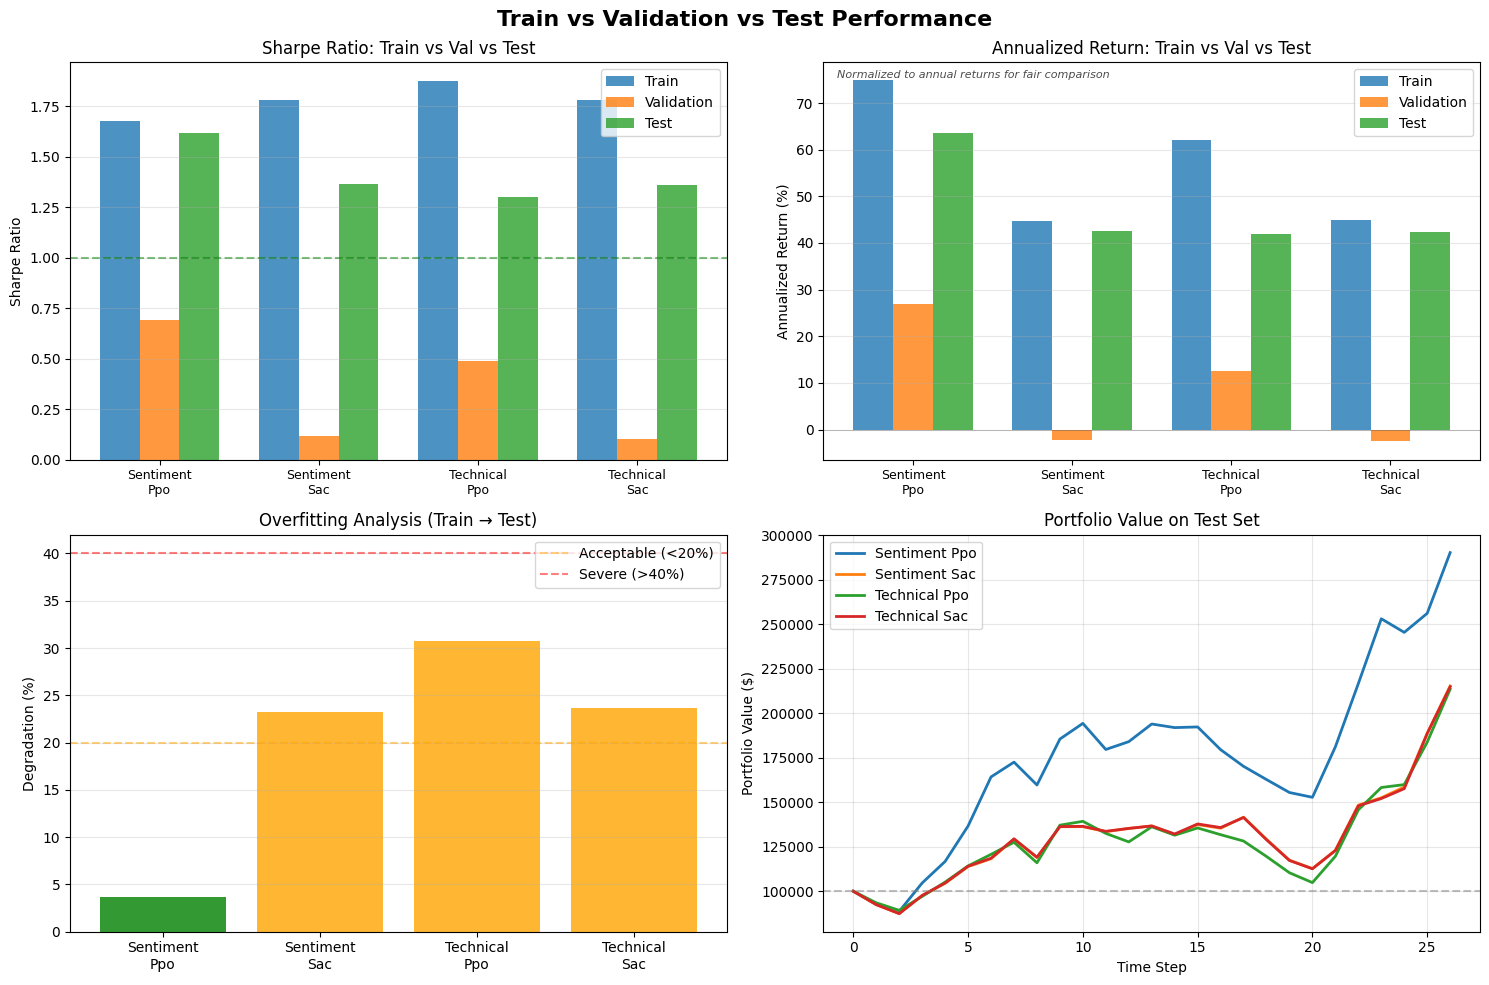

In [ ]:
# Plot comprehensive comparison
fig = plot_train_val_test_comparison(results)
plt.show()

# Plot learning curves for each agent


In [9]:

print("Models Saved")

print("\nBest models (selected by validation performance) saved in:")
for name in results.keys():
    model_path = f"{training_config['save_path']}/{name}/best_model.zip"
    print(f"  {model_path}")

Models Saved

Best models (selected by validation performance) saved in:
  ./models//sentiment_ppo/best_model.zip
  ./models//sentiment_sac/best_model.zip
  ./models//technical_ppo/best_model.zip
  ./models//technical_sac/best_model.zip
